# 03. Feature Engineering — Fase 3.5

Refina las bases procesadas de Fase 3 (`*_procesado.parquet`) para dejarlas listas
para modelado. **No entrena.** Tareas:

1. Filtro de cohorte (edad ≥ 18 — 0 positivos bajo 21 años).
2. Eliminación de redundancia: pares de flags 100% idénticos y columnas constantes.
3. Labs faltantes = **no tomados** (MNAR) — se mantiene `{lab}_disponible` como señal.
4. Winsorización de outliers (errores de digitación: TRIGLICERIDOS máx 228.000, etc.).
5. QQ plots → transformación log1p para variables con sesgo extremo.
6. Correlación / multicolinealidad.
7. Encoding de categóricas.
8. Selección de características (mutual information).
9. Guardado de bases listas para modelo.

> Medianas / parámetros se calculan en **train** y se aplican a **validación** (anti-leakage).


In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

train = pd.read_parquet("bases/prediccion_mama_train_procesado.parquet")
val   = pd.read_parquet("bases/prediccion_mama_val_procesado.parquet")
print("train", train.shape, "| val", val.shape)
print("positivos train", int(train.label.sum()), "| val", int(val.label.sum()))


train (4286080, 69) | val (2410807, 69)
positivos train 1857 | val 993


## 1. Cohorte — edad ≥ 18 (verificación)

El filtro de cohorte ahora se aplica **aguas arriba**, en Fase 3 (`02. revision bases.ipynb`),
**antes de imputar**, para que las medianas/moda se calculen sobre la cohorte de modelado
(los menores sesgan a la baja PESO/TALLA/IMC/MENARQUIA). Bajo 18: 21,66% de la población y
**0 positivos** (mínimo positivo = 21 años). Aquí solo se verifica.


In [2]:
assert train['edad'].min() >= 18, f"train trae menores: edad min {train['edad'].min()}"
assert val['edad'].min()   >= 18, f"val trae menores: edad min {val['edad'].min()}"
print(f"Cohorte OK (edad min train {train['edad'].min():.0f} / val {val['edad'].min():.0f})")
print(f"Event rate train {train.label.mean()*100:.4f}% | val {val.label.mean()*100:.4f}%")


Cohorte OK (edad min train 18 / val 18)
Event rate train 0.0433% | val 0.0412%


## 2. Eliminación de redundancia

**Pares 100% idénticos** (corr=1.0, verificado en diagnóstico): `hta`==`ant_hta`,
`dm`==`ant_dm`, `biopsia`==`ant_biopsia`, `cancer`==`ant_cancer`. Se conserva el nombre
base y se elimina el `ant_*` duplicado.

**Columnas constantes** (una sola categoría → 0 información): `ant_mama`, `cie_hta`,
`cie_dm`, `cie_biopsia`, `cie_cancer`, `cie_mama` (todas 0); `imc_disponible` (todas 1).


In [3]:
DROP_REDUNDANTE = ['ant_hta', 'ant_dm', 'ant_biopsia', 'ant_cancer']
DROP_CONSTANTE  = ['ant_mama', 'cie_hta', 'cie_dm', 'cie_biopsia', 'cie_cancer',
                   'cie_mama', 'imc_disponible']

# Verificar que siguen constantes en train (defensivo)
for c in DROP_CONSTANTE:
    if c in train.columns:
        assert train[c].nunique() == 1, f"{c} ya no es constante: {train[c].nunique()} valores"

for df in (train, val):
    df.drop(columns=[c for c in DROP_REDUNDANTE + DROP_CONSTANTE if c in df.columns],
            inplace=True)
print("train", train.shape, "| val", val.shape)


train (4286080, 58) | val (2410807, 58)


## 3. Labs faltantes = no tomados (MNAR)

La ausencia de un laboratorio **no es aleatoria**: el lab se ordena ante sospecha clínica.
Por eso el indicador `{lab}_disponible` (creado en Fase 3) es informativo por sí mismo y se
conserva. Los valores faltantes ya fueron imputados con la **mediana de train**; aquí solo
verificamos que los `_disponible` no sean constantes y que aporten señal.


In [4]:
disp_cols = [c for c in train.columns if c.endswith('_disponible')]
rows = []
for c in disp_cols:
    rp = train.loc[train.label==1, c].mean()
    rn = train.loc[train.label==0, c].mean()
    rows.append({'feature': c, 'rate_pos': rp, 'rate_neg': rn,
                 'lift': rp/rn if rn>0 else np.nan, 'nunique': train[c].nunique()})
disp_stats = pd.DataFrame(rows).sort_values('lift', ascending=False)
print(disp_stats.to_string(index=False, float_format='{:.4f}'.format))
# Si alguno quedó constante, marcar para drop
const_disp = [c for c in disp_cols if train[c].nunique() == 1]
print("\n_disponible constantes (drop):", const_disp)
for df in (train, val):
    df.drop(columns=[c for c in const_disp if c in df.columns], inplace=True)


                                 feature  rate_pos  rate_neg   lift  nunique
      HEMOGLOBINA_GLICOSILADA_disponible    0.1039    0.0443 2.3439        2
delta_HEMOGLOBINA_GLICOSILADA_disponible    0.0393    0.0197 1.9966        2
                TRIGLICERIDOS_disponible    0.2046    0.1077 1.8996        2
             COLESTEROL_TOTAL_disponible    0.2057    0.1087 1.8921        2
               COLESTEROL_HDL_disponible    0.2014    0.1068 1.8856        2
               COLESTEROL_LDL_disponible    0.1761    0.0964 1.8272        2
         delta_COLESTEROL_HDL_disponible    0.0614    0.0361 1.7013        2
                  riesgo_alto_disponible    0.0883    0.0521 1.6948        2
       delta_COLESTEROL_TOTAL_disponible    0.0614    0.0371 1.6565        2
          delta_TRIGLICERIDOS_disponible    0.0603    0.0367 1.6435        2
          PERIMETRO_ABDOMINAL_disponible    0.2989    0.1949 1.5333        2
         delta_COLESTEROL_LDL_disponible    0.0463    0.0305 1.5176        2


_disponible constantes (drop): []


## 4. Winsorización de outliers

Los extremos de labs/antropometría son **errores de digitación** (TRIGLICERIDOS=228.000,
COLESTEROL_LDL negativo, IMC=829). Se recortan a límites de **plausibilidad clínica** para
eliminar el artefacto sin descartar filas. Los valores imputados (mediana) caen dentro de
estos límites, por lo que no se ven afectados; solo se corrigen los extremos no fisiológicos.

Límites como cota de plausibilidad (no afirmación clínica), simétricos train/val:


In [5]:
# (col, min, max) — cotas de plausibilidad fisiológica para winsorizar errores de captura
CLIP_BOUNDS = {
    'edad':                       (18, 110),
    'IMC':                        (12, 70),
    'PESO':                       (30, 250),
    'TALLA':                      (120, 210),
    'PERIMETRO_ABDOMINAL':        (40, 200),
    'MENARQUIA':                  (8, 20),
    'TENSION_ARTERIAL_SISTOLE':   (70, 250),
    'TENSION_ARTERIAL_DIASTOLE':  (40, 150),
    'COLESTEROL_TOTAL':           (50, 500),
    'COLESTEROL_HDL':             (10, 150),
    'COLESTEROL_LDL':             (10, 400),
    'TRIGLICERIDOS':              (20, 2000),
    'HEMOGLOBINA_GLICOSILADA':    (3, 20),
}
# n_consultas_T: conteo sin máximo clínico; cota superior en p99.9 de train
N_CONS_CAP = float(train['n_consultas_T'].quantile(0.999))
print("n_consultas_T cap (p99.9 train):", N_CONS_CAP)

def winsoriza(df):
    for c, (lo, hi) in CLIP_BOUNDS.items():
        if c in df.columns:
            df[c] = df[c].clip(lo, hi)
    if 'n_consultas_T' in df.columns:
        df['n_consultas_T'] = df['n_consultas_T'].clip(0, N_CONS_CAP)
    return df

train = winsoriza(train); val = winsoriza(val)
print("\n=== describe post-winsorización (train) ===")
print(train[list(CLIP_BOUNDS)].describe().T[['min','50%','max']].to_string(float_format='{:.2f}'.format))


n_consultas_T cap (p99.9 train): 53.0



=== describe post-winsorización (train) ===


                             min    50%     max
edad                       18.00  40.00  110.00
IMC                        12.00  26.04   70.00
PESO                       30.00  65.00  250.00
TALLA                     120.00 158.00  210.00
PERIMETRO_ABDOMINAL        40.00  87.00  200.00
MENARQUIA                   8.00  12.00   20.00
TENSION_ARTERIAL_SISTOLE   70.00 116.00  250.00
TENSION_ARTERIAL_DIASTOLE  40.00  70.00  150.00
COLESTEROL_TOTAL           50.00 189.00  500.00
COLESTEROL_HDL             10.00  48.20  150.00
COLESTEROL_LDL             10.00 108.00  400.00
TRIGLICERIDOS              20.00 137.00 2000.00
HEMOGLOBINA_GLICOSILADA     3.00   6.20   20.00


## 5. Redundancia PESO vs IMC

`IMC = PESO / TALLA²`, con correlación PESO~IMC ≈ 0,87. Para decidir cuál conservar se compara
el **missingness real** (antes de imputar) usando los indicadores `_disponible`: IMC requiere
PESO **y** TALLA disponibles.

Resultado (cohorte ≥18): PESO faltante ≈ 40,4% vs IMC ≈ 40,7% — **prácticamente empatados**
(solo ~12,7k filas con PESO pero sin TALLA). El desempate es **clínico**: IMC mide adiposidad
(factor de riesgo establecido de cáncer de mama, sobre todo posmenopáusico), mientras PESO crudo
está confundido por la estatura. Se conserva **IMC** y se elimina **PESO**; `TALLA` permanece como
señal de estatura independiente.


In [6]:
peso_miss  = 1 - train['PESO_disponible'].mean()
talla_miss = 1 - train['TALLA_disponible'].mean()
imc_miss   = 1 - (train['PESO_disponible'] * train['TALLA_disponible']).mean()  # AND
print(f"PESO  faltante: {peso_miss*100:6.2f}%")
print(f"TALLA faltante: {talla_miss*100:6.2f}%")
print(f"IMC   faltante: {imc_miss*100:6.2f}%  (requiere PESO Y TALLA)")
print(f"Diferencia IMC-PESO: {(imc_miss-peso_miss)*100:.2f} pp")

# Decisión: conservar IMC (clínicamente superior), eliminar PESO. PESO_disponible ≈ IMC avail → también se elimina por redundancia.
DROP_PESO = ['PESO', 'PESO_disponible']
for df in (train, val):
    df.drop(columns=[c for c in DROP_PESO if c in df.columns], inplace=True)
print("\nEliminadas:", DROP_PESO, "| train", train.shape)


PESO  faltante:  40.37%
TALLA faltante:  38.40%
IMC   faltante:  40.66%  (requiere PESO Y TALLA)
Diferencia IMC-PESO: 0.30 pp



Eliminadas: ['PESO', 'PESO_disponible'] | train (4286080, 56)


## 6. Transformación log1p — decisión por métricas de QQ

En vez de un umbral de sesgo simple, se usa `find_log1p_candidates` (módulo `utils/fe_qq.py`):
recomienda `log1p` solo cuando el QQ raw muestra **curvatura real en la cola derecha**
(skew alto + `tail_lift_z` + monotonía) **y** la transformada se endereza de forma medible
(reducción de `qq_rmse` y de `tail_lift_z`). Esto descarta automáticamente las labs con masa
puntual (90-97% imputado a la mediana), donde el log no corrige nada.

Las gráficas muestran cada variable raw con su log1p **debajo**, para inspección visual.


In [7]:
from utils.fe_qq import plot_qq_raw_vs_log1p, find_log1p_candidates

SAMPLE = train.sample(min(100000, len(train)), random_state=42)
CONT = ['edad','n_consultas_T','IMC','TALLA','PERIMETRO_ABDOMINAL','MENARQUIA',
        'TENSION_ARTERIAL_SISTOLE','TENSION_ARTERIAL_DIASTOLE',
        'COLESTEROL_TOTAL','COLESTEROL_HDL','COLESTEROL_LDL','TRIGLICERIDOS','HEMOGLOBINA_GLICOSILADA']
CONT = [c for c in CONT if c in train.columns]

rec = find_log1p_candidates(SAMPLE, CONT)
show_cols = ['variable','raw_skew','raw_qq_rmse','log_qq_rmse','rmse_improve_pct',
             'raw_tail_lift_z','log_tail_lift_z','tail_improve_pct',
             'raw_right_bend','log_straighter','recommend_log1p']
print("=== Recomendador log1p (find_log1p_candidates) ===")
print(rec[show_cols].to_string(index=False, float_format='{:.3f}'.format))

LOG_VARS = rec.loc[rec['recommend_log1p'], 'variable'].tolist()
print("\nLOG_VARS recomendadas:", LOG_VARS)


=== Recomendador log1p (find_log1p_candidates) ===
                 variable  raw_skew  raw_qq_rmse  log_qq_rmse  rmse_improve_pct  raw_tail_lift_z  log_tail_lift_z  tail_improve_pct  raw_right_bend  log_straighter  recommend_log1p
            TRIGLICERIDOS    11.339       24.872        0.122            99.511            0.326           -0.069            78.757           False            True            False
         COLESTEROL_TOTAL     2.552       12.278        0.063            99.487            0.030           -0.195          -559.291           False           False            False
                    TALLA    -0.432        1.751        0.012            99.329            0.421            0.263            37.441           False            True            False
 TENSION_ARTERIAL_SISTOLE     1.467        3.506        0.027            99.241            0.249           -0.001            99.610           False            True            False
           COLESTEROL_LDL     2.881       10

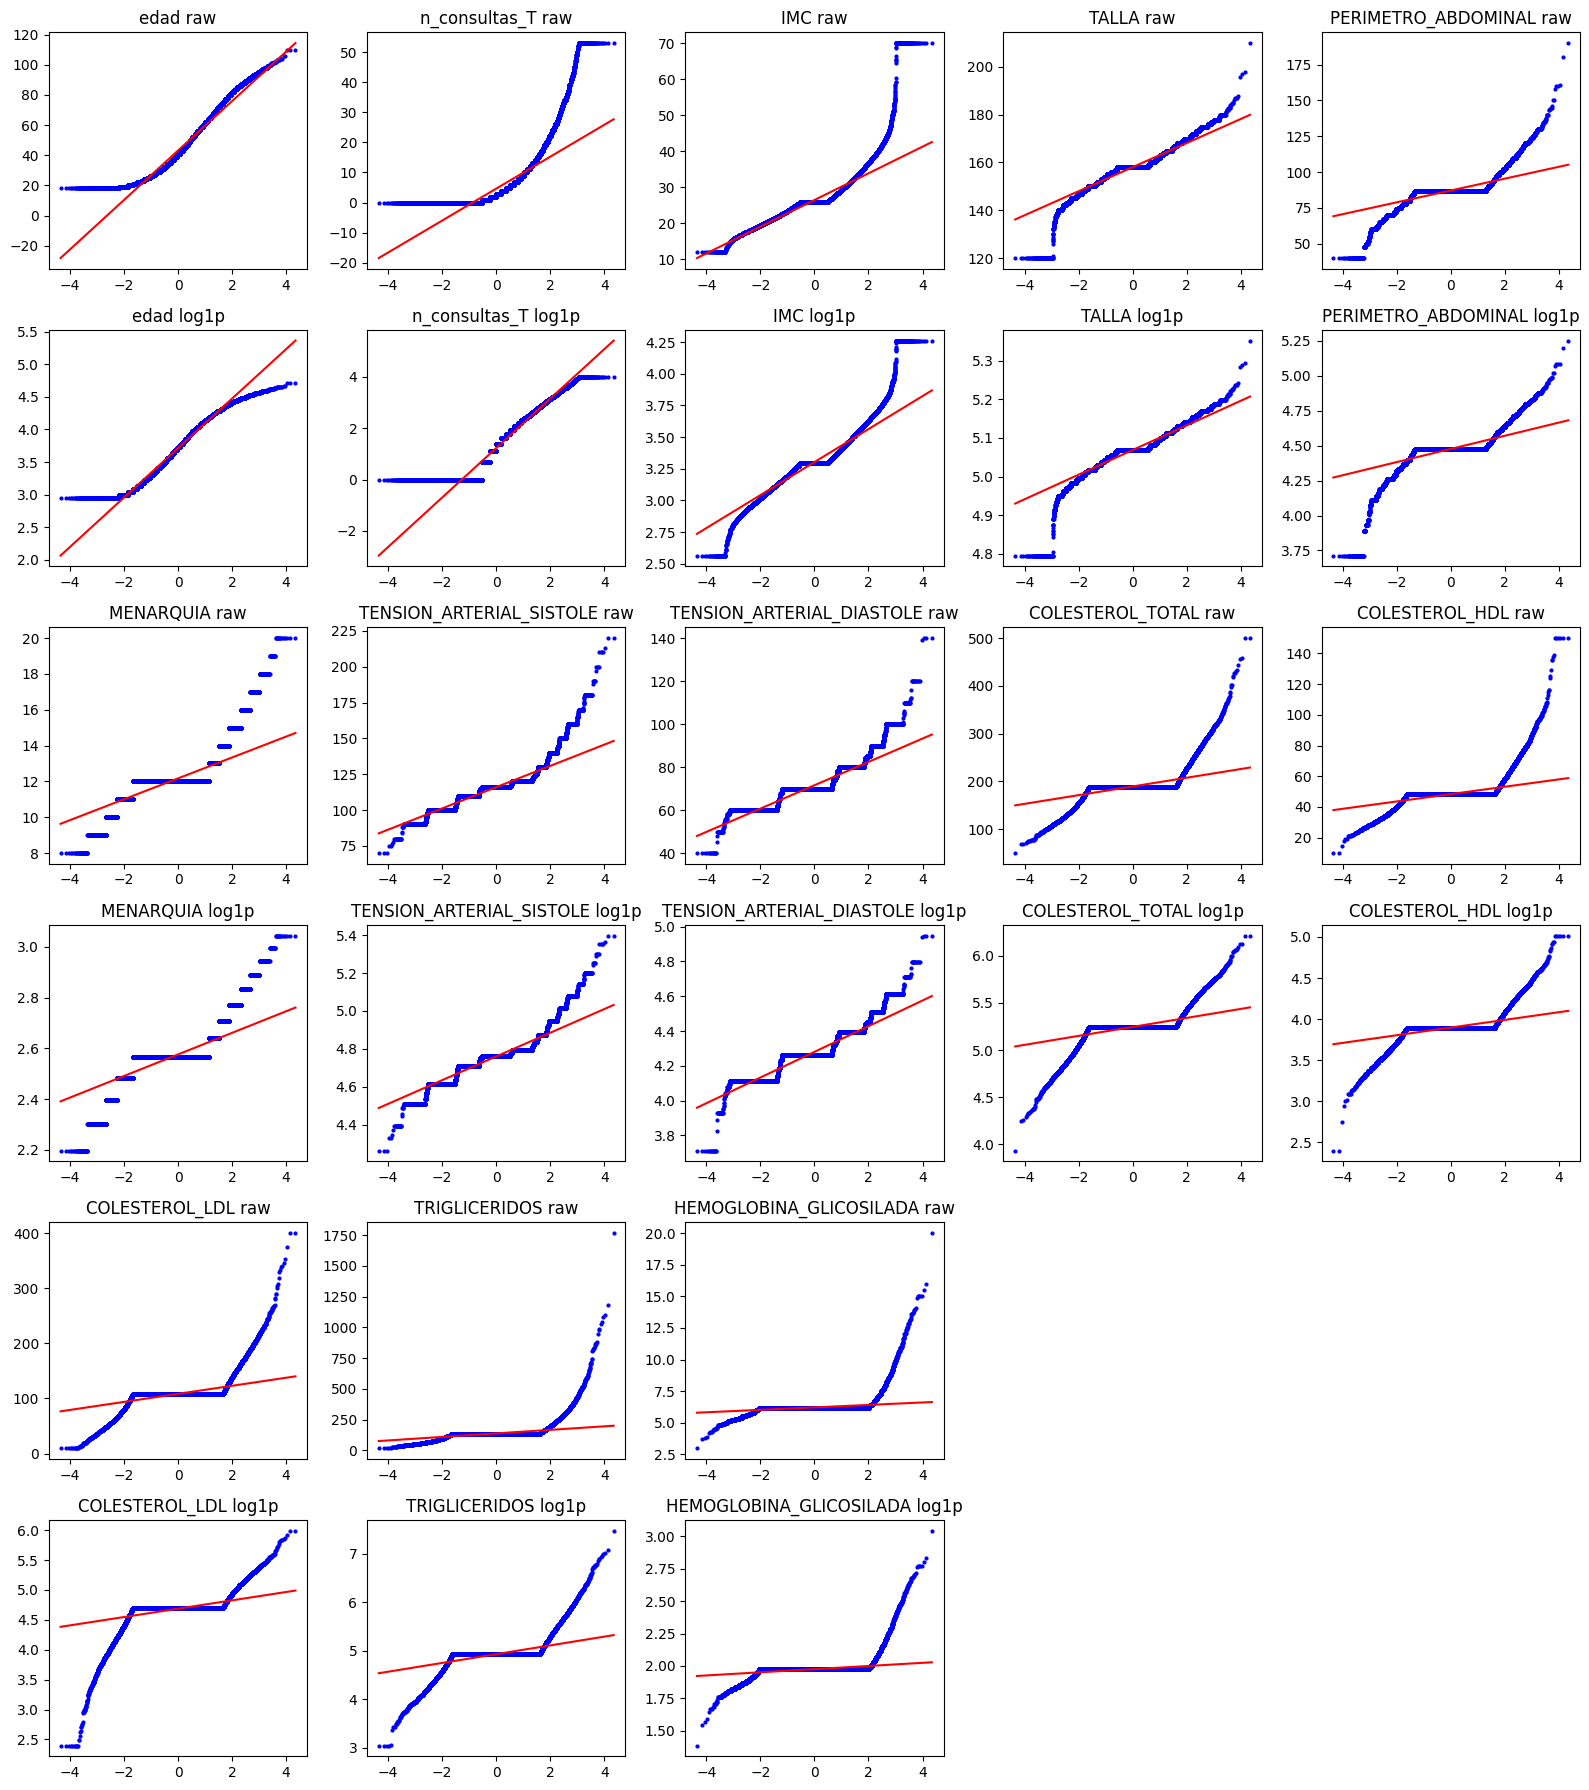

In [8]:
# QQ raw vs log1p (muestra) — transformada debajo de su versión cruda
fig, _ = plot_qq_raw_vs_log1p(SAMPLE, CONT, max_cols=5, marker_size=2)
plt.show()


In [9]:
# Aplicar solo las transformaciones recomendadas
for df in (train, val):
    for c in LOG_VARS:
        df[c] = np.log1p(df[c].clip(lower=0))
print("Transformadas:", LOG_VARS)
print("\n=== Sesgo final (train) ===")
print(train[CONT].skew().sort_values(ascending=False).to_string(float_format='{:.3f}'.format))


Transformadas: []

=== Sesgo final (train) ===


TRIGLICERIDOS               15.575
HEMOGLOBINA_GLICOSILADA     15.057
COLESTEROL_HDL               4.846
MENARQUIA                    2.609
COLESTEROL_LDL               2.576
n_consultas_T                2.576
IMC                          2.418
COLESTEROL_TOTAL             2.292
TENSION_ARTERIAL_SISTOLE     1.483
PERIMETRO_ABDOMINAL          0.936
TENSION_ARTERIAL_DIASTOLE    0.935
edad                         0.624
TALLA                       -0.425


**Conclusión — ninguna variable se transforma (`LOG_VARS = []`).**

El recomendador no marca ninguna porque `right_tail_monotone ≈ 0` en todas (la cola derecha no
sube de forma suave). La no-normalidad residual no proviene de una cola larga que el log
endereza, sino de:
1. **Masa puntual de imputación** — 90-97% de las labs quedan en la mediana de train; el log de
   una masa puntual sigue siendo una masa puntual.
2. **Granularidad/discretización** — p. ej. `n_consultas_T` (conteo), `MENARQUIA` (entero).

El pile-up en el techo de winsorización es despreciable (<0,11%), así que no es artefacto del
clipping. Conclusión: **transformar log1p no mejoraría la forma**. Para los modelos de árbol
(candidatos principales) las transformaciones monótonas son irrelevantes; para el baseline lineal
se recurrirá a estandarización y a los indicadores `{var}_disponible`, no a log. El umbral de
sesgo simple habría transformado de más; el criterio de forma del QQ lo evita.


## 7. Correlación y multicolinealidad

Se revisa correlación de Pearson entre continuas para detectar redundancia. Con `PESO` ya
eliminado, se verifica que no queden pares fuertemente colineales. Los árboles toleran
colinealidad; para el baseline lineal se documenta para posible reducción.


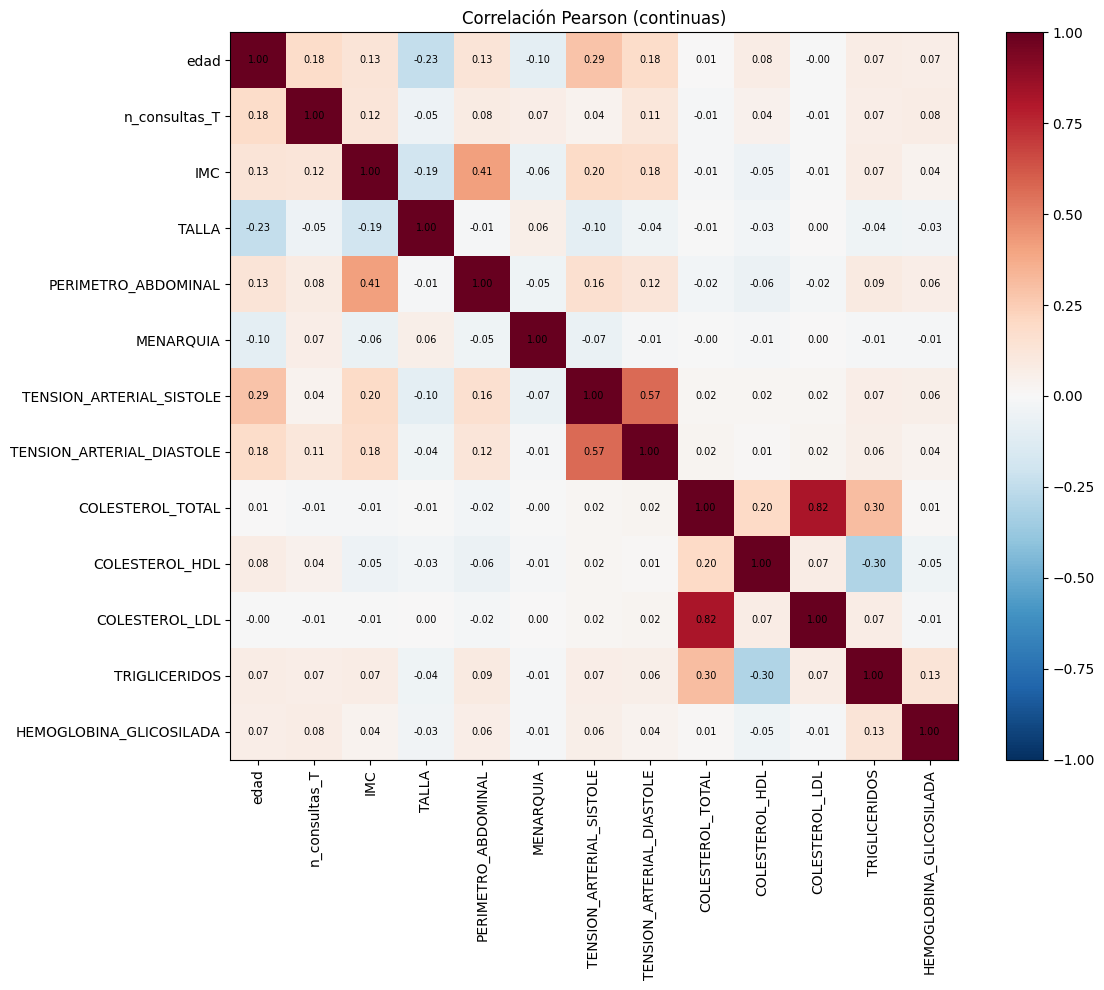

=== Pares |corr|>0.6 ===
  COLESTEROL_TOTAL ~ COLESTEROL_LDL: 0.820


In [10]:
corr = train[CONT].corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(CONT))); ax.set_xticklabels(CONT, rotation=90)
ax.set_yticks(range(len(CONT))); ax.set_yticklabels(CONT)
for i in range(len(CONT)):
    for j in range(len(CONT)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=7)
plt.colorbar(im, fraction=0.046); plt.title("Correlación Pearson (continuas)"); plt.tight_layout(); plt.show()

print("=== Pares |corr|>0.6 ===")
for i in range(len(CONT)):
    for j in range(i+1, len(CONT)):
        v = corr.iloc[i, j]
        if abs(v) > 0.6:
            print(f"  {CONT[i]} ~ {CONT[j]}: {v:.3f}")


## 8. Encoding de categóricas

- `ZONA` (urbano/rural) → one-hot.
- `DESCRIP_REGIONAL` (baja cardinalidad) → one-hot.
- `cod_municip` (alta cardinalidad) → frequency encoding (`municip_freq`); se elimina el código crudo.
- `key` se conserva **fuera de la matriz de features** para GroupKFold.
- `anio` se mantiene como entero (identificador del par T→T+1).


In [11]:
print("ZONA valores:", train['ZONA'].value_counts().to_dict())
print("DESCRIP_REGIONAL nunique:", train['DESCRIP_REGIONAL'].nunique())
print("cod_municip nunique:", train['cod_municip'].nunique())

# frequency encoding de municipio (calculado en train)
muni_freq = train['cod_municip'].value_counts(normalize=True)
for df in (train, val):
    df['municip_freq'] = df['cod_municip'].map(muni_freq).fillna(0.0)

# one-hot ZONA y DESCRIP_REGIONAL (categorías de train)
def onehot(df, cols, ref):
    d = pd.get_dummies(df, columns=cols, prefix=cols, dummy_na=False)
    # alinear a columnas de referencia (train)
    if ref is not None:
        for c in ref:
            if c not in d.columns:
                d[c] = 0
        d = d[[c for c in d.columns if c in ref] + [c for c in d.columns if c not in ref]]
    return d

train = pd.get_dummies(train, columns=['ZONA','DESCRIP_REGIONAL'], prefix=['ZONA','REG'], dummy_na=False)
val   = pd.get_dummies(val,   columns=['ZONA','DESCRIP_REGIONAL'], prefix=['ZONA','REG'], dummy_na=False)
# alinear columnas val a train
for c in train.columns:
    if c not in val.columns:
        val[c] = 0
val = val[train.columns]

for df in (train, val):
    df.drop(columns=['cod_municip'], inplace=True)

print("\ntrain", train.shape, "| val", val.shape)
print("dtypes:\n", train.dtypes.value_counts())


ZONA valores: {'U': 4050428, 'R': 235652}


DESCRIP_REGIONAL nunique:

 6
cod_municip nunique: 508



train (4286080, 62) | val (2410807, 62)
dtypes:
 int64      27
float64    25
bool        8
object      1
int32       1
Name: count, dtype: int64


## 9. Selección de características — Mutual Information

MI entre cada feature y `label`. Por el desbalance (~3000:1) se usa una muestra estratificada
que conserva todos los positivos y un submuestreo de negativos, para estimación estable y rápida.
MI captura relaciones no lineales (complementa Cohen's d / odds ratio de Fase 3).

> ⚠️ **Dos cautelas al leer el ranking:**
> 1. **Sesgo de vigilancia:** los indicadores `_disponible`, `tiene_avicena` y `n_consultas_T`
>    suben alto porque las positivas usan más el sistema de salud (donde se detecta el cáncer),
>    no por riesgo intrínseco. Son válidos como proxy de acceso y están disponibles al momento
>    de scoring, pero conviene un análisis de sensibilidad con/sin ellos en Fase 4.
> 2. **MI subestima continuas monótonas:** `edad` (Cohen's d 1,21, el efecto más fuerte en
>    Fase 3) cae al fondo del MI por el estimador k-NN sobre variable continua con desbalance.
>    Cruzar siempre MI con los tamaños de efecto de Fase 3, no usarlo aislado para descartar.


In [12]:
from sklearn.feature_selection import mutual_info_classif

NON_FEATURES = ['key', 'label']
feat_cols = [c for c in train.columns if c not in NON_FEATURES]
# convertir bool a int
Xtr = train[feat_cols].astype('float32')
ytr = train['label'].values

# muestra: todos positivos + 200k negativos
pos_idx = np.where(ytr == 1)[0]
neg_idx = np.random.RandomState(42).choice(np.where(ytr == 0)[0], size=200000, replace=False)
sel = np.concatenate([pos_idx, neg_idx])
mi = mutual_info_classif(Xtr.iloc[sel], ytr[sel], random_state=42, n_jobs=-1)
mi_rank = pd.Series(mi, index=feat_cols).sort_values(ascending=False)
print("=== Mutual Information vs label (top 30) ===")
print(mi_rank.head(30).to_string(float_format='{:.5f}'.format))
print("\n=== Features con MI ~ 0 (candidatas a descartar) ===")
print(mi_rank[mi_rank < 1e-5].index.tolist())


=== Mutual Information vs label (top 30) ===
ZONA_U                                 0.05651
COLESTEROL_LDL                         0.05063
TRIGLICERIDOS                          0.04760
tiene_avicena                          0.04427
HEMOGLOBINA_GLICOSILADA                0.04317
TENSION_ARTERIAL_SISTOLE_disponible    0.04139
TALLA_disponible                       0.04082
TENSION_ARTERIAL_DIASTOLE_disponible   0.04004
COLESTEROL_HDL                         0.03779
COLESTEROL_TOTAL                       0.03401
MENARQUIA                              0.02399
PERIMETRO_ABDOMINAL                    0.02323
TENSION_ARTERIAL_DIASTOLE              0.02053
REG_1 REG BOGOTA                       0.01906
proxy_menopausia                       0.01657
anio                                   0.01560
municip_freq                           0.01378
n_consultas_T                          0.01131
TENSION_ARTERIAL_SISTOLE               0.01014
MENARQUIA_disponible                   0.00858
TALLA          

## 10. Guardar bases listas para modelo

- `bases/prediccion_mama_train_modelo.parquet`
- `bases/prediccion_mama_val_modelo.parquet`
- `bases/fe_params.json` — parámetros derivados de train (caps, log vars, muni_freq, columnas) para reproducir en producción.


In [13]:
train.to_parquet("bases/prediccion_mama_train_modelo.parquet", index=False)
val.to_parquet("bases/prediccion_mama_val_modelo.parquet", index=False)

fe_params = {
    'cohorte_edad_min': 18,
    'drop_redundante': DROP_REDUNDANTE,
    'drop_constante': DROP_CONSTANTE,
    'drop_peso': DROP_PESO,
    'clip_bounds': CLIP_BOUNDS,
    'n_consultas_cap': N_CONS_CAP,
    'log_vars': LOG_VARS,
    'municip_freq': {str(k): float(v) for k, v in muni_freq.items()},
    'feature_columns': [c for c in train.columns if c not in ('key','label')],
    'mi_ranking': {k: float(v) for k, v in mi_rank.items()},
}
with open("bases/fe_params.json", "w", encoding="utf-8") as f:
    json.dump(fe_params, f, indent=2, ensure_ascii=False)

print("Guardado:")
print(f"  train_modelo  {train.shape}  positivos {int(train.label.sum())}")
print(f"  val_modelo    {val.shape}  positivos {int(val.label.sum())}")
print(f"  n features    {len(fe_params['feature_columns'])}")
print(f"  nulos train {int(train.isnull().sum().sum())} | val {int(val.isnull().sum().sum())}")


Guardado:
  train_modelo  (4286080, 62)  positivos 1857
  val_modelo    (2410807, 62)  positivos 993
  n features    60


  nulos train 0 | val 0
